## Modelo S com Optuna e sem data augmentation

In [1]:
#imports
from keras.utils import image_dataset_from_directory
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
import optuna
import tensorflow as tf
from keras import layers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


c:\Users\gonca\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_dir = 'train'
validation_dir = 'validation'
test_dir = 'test'

IMG_SIZE = 32

train_dataset = image_dataset_from_directory(train_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32) 
validation_dataset = image_dataset_from_directory(validation_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)
test_dataset = image_dataset_from_directory(test_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

Found 40000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


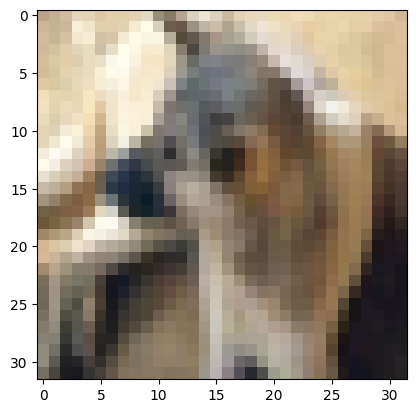

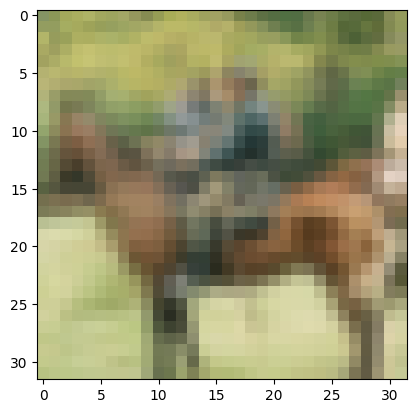

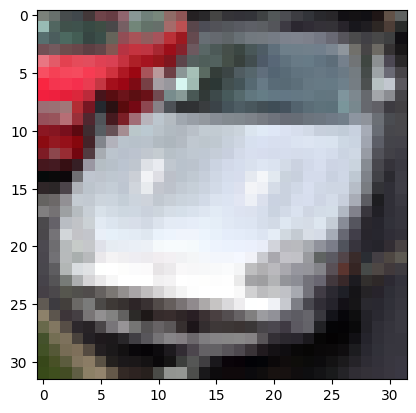

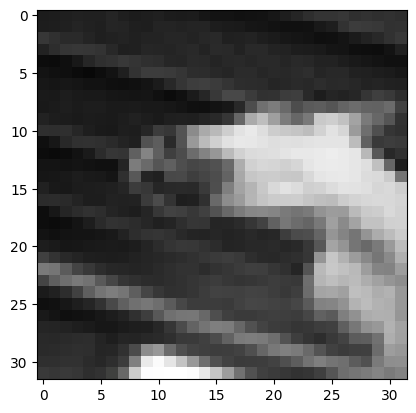

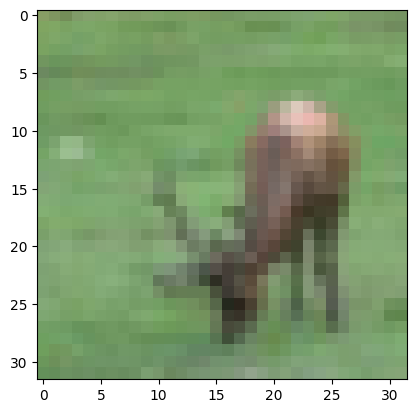

In [3]:
# import matplotlib.pyplot as plt

for data_batch, _ in train_dataset.take(1):
  for i in range(5):
    plt.imshow(data_batch[i].numpy().astype("uint8"))
    plt.show()

In [10]:

model_filename = 'model_s_no_augmentation.keras'

# using optuna to optimize hyperparameters
def objective(trial):
    inputs = keras.Input(shape=(32, 32, 3))

    l2_regularizer = trial.suggest_float('l2_regularizer', 1e-4, 1e-2)
    dropout1 = trial.suggest_float('dropout1', 0.0, 0.5)
    dropout2 = trial.suggest_float('dropout2', 0.0, 0.5)
    dropout3 = trial.suggest_float('dropout3', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2)

    x = layers.Conv2D(filters=50, kernel_size=3, activation="relu")(inputs)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Dropout(dropout1)(x)

    x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Flatten()(x)

    x = layers.Dropout(dropout2)(x)
    x = layers.Dense(100, activation="relu")(x)
    x = layers.Dropout(dropout3)(x)
    x = layers.Dense(25, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.RMSprop(learning_rate=learning_rate), metrics=['acc'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # para salvar o melhor modelo
    checkpoint_callback = ModelCheckpoint(
        model_filename,
        monitor='val_acc', 
        save_best_only=True,
        mode='max',
        save_weights_only=False
    )

    # Training the model
    history = model.fit(train_dataset, epochs=100, validation_data=validation_dataset, callbacks=[early_stopping, checkpoint_callback])

    val_loss, val_accuracy = model.evaluate(validation_dataset, verbose=0)
    
    return val_accuracy

In [11]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, timeout=10000)

study.best_params

[I 2024-06-21 18:41:29,759] A new study created in memory with name: no-name-a9fc6d0f-f258-4512-af7e-eeac22816154


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 29ms/step - acc: 0.1038 - loss: 14.1588 - val_acc: 0.0983 - val_loss: 2.3044
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - acc: 0.0994 - loss: 2.3037 - val_acc: 0.0983 - val_loss: 2.3042
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - acc: 0.1022 - loss: 2.3037 - val_acc: 0.0983 - val_loss: 2.3043
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - acc: 0.1020 - loss: 2.3036 - val_acc: 0.0983 - val_loss: 2.3043
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - acc: 0.1032 - loss: 2.3036 - val_acc: 0.0983 - val_loss: 2.3045
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - acc: 0.1010 - loss: 2.3037 - val_acc: 0.0983 - val_loss: 2.3043
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - acc: 0.1022 - loss: 2.3036 - val_acc: 0.0983 - val_loss: 2.3044


[I 2024-06-21 18:45:44,070] Trial 0 finished with value: 0.09830000251531601 and parameters: {'l2_regularizer': 0.004647208739342863, 'dropout1': 0.21617588596247617, 'dropout2': 0.4743583775515892, 'dropout3': 0.15032825280880885, 'learning_rate': 0.007480790536734094}. Best is trial 0 with value: 0.09830000251531601.


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - acc: 0.1068 - loss: 11.0695 - val_acc: 0.0983 - val_loss: 2.3045
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - acc: 0.0992 - loss: 2.3037 - val_acc: 0.0983 - val_loss: 2.3043
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - acc: 0.0999 - loss: 2.3037 - val_acc: 0.0983 - val_loss: 2.3042
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - acc: 0.1007 - loss: 2.3036 - val_acc: 0.0983 - val_loss: 2.3043
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - acc: 0.1029 - loss: 2.3037 - val_acc: 0.0983 - val_loss: 2.3042
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - acc: 0.0997 - loss: 2.3037 - val_acc: 0.0983 - val_loss: 2.3043
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - acc: 0.1003 - loss: 2.3037 - val_acc: 0.0983 - val_loss: 2.3044
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - acc: 0.1012 - loss: 2.3036 - val_acc: 0.1003 - val_loss: 2.3043


[I 2024-06-21 18:50:22,785] Trial 1 finished with value: 0.09830000251531601 and parameters: {'l2_regularizer': 0.005658377182188932, 'dropout1': 0.008400367887530347, 'dropout2': 0.4601361365725045, 'dropout3': 0.34383858804682554, 'learning_rate': 0.007566275057809157}. Best is trial 0 with value: 0.09830000251531601.


...

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - acc: 0.1312 - loss: 11.9774 - val_acc: 0.2300 - val_loss: 2.0091
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - acc: 0.2392 - loss: 2.0277 - val_acc: 0.2609 - val_loss: 1.9964
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - acc: 0.2612 - loss: 1.9699 - val_acc: 0.2687 - val_loss: 1.9584
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - acc: 0.2705 - loss: 1.9575 - val_acc: 0.2758 - val_loss: 1.8792
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - acc: 0.2834 - loss: 1.9290 - val_acc: 0.2983 - val_loss: 1.8599
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - acc: 0.2882 - loss: 1.9293 - val_acc: 0.3054 - val_loss: 1.8453
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - acc: 0.2905 - loss: 1.9128 - val_acc: 0.2672 - val_loss: 1.9365
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - acc: 0.2935 - loss: 1.9127 - val_acc: 0.3158 - val_loss: 1.8650
Epoch 9/100
125

[I 2024-06-21 21:20:04,610] Trial 17 finished with value: 0.305400013923645 and parameters: {'l2_regularizer': 0.004027074274645171, 'dropout1': 0.18737414187890689, 'dropout2': 0.11397456638757551, 'dropout3': 0.41327531265419126, 'learning_rate': 0.0047216211140525535}. Best is trial 16 with value: 0.7498000264167786.


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - acc: 0.1673 - loss: 3.1846 - val_acc: 0.3418 - val_loss: 1.8117
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - acc: 0.3272 - loss: 1.8933 - val_acc: 0.3960 - val_loss: 1.6658
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.3707 - loss: 1.8002 - val_acc: 0.4241 - val_loss: 1.6730
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.3898 - loss: 1.7517 - val_acc: 0.4394 - val_loss: 1.6726
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - acc: 0.4017 - loss: 1.7510 - val_acc: 0.4041 - val_loss: 1.7493
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - acc: 0.4121 - loss: 1.7287 - val_acc: 0.4181 - val_loss: 1.7356
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - acc: 0.4168 - loss: 1.7169 - val_acc: 0.4491 - val_loss: 1.6129
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - acc: 0.4186 - loss: 1.7210 - val_acc: 0.4588 - val_loss: 1.6368
Epoch 9/100
1250

[I 2024-06-21 21:29:50,131] Trial 18 finished with value: 0.48730000853538513 and parameters: {'l2_regularizer': 0.0032323388457625654, 'dropout1': 0.16927811714858654, 'dropout2': 0.18577087259343134, 'dropout3': 0.4004589162257366, 'learning_rate': 0.002012880346373621}. Best is trial 16 with value: 0.7498000264167786.


{'l2_regularizer': 0.003792128273028032,
 'dropout1': 0.19005420495449035,
 'dropout2': 0.1505291713450001,
 'dropout3': 0.4254195152408111,
 'learning_rate': 0.00015257504683825857}

Em cima aparecem aqueles que o Optuna considera serem os melhores parâmetros para o modelo que, embora ligeiramente diferentes dos definidos no modelo_s.ipynb, resultam numa accuracy de validação bastante semelhante.
Conseguimos perceber pelos valores das accuracies de validação que o Optuna encontrou uma combinação de hiperparâmetros que resultou numa accuracy de validação bastante boa e em que não ocorre overfitting. 
Na transição de certos trials dá-se uma grande descida na accuracy que não seria de esperar. Uma das razões para tal acontecer pode ser o facto de que o Optuna, ao tentar encontrar melhores hiperparâmetros, por vezes altera valores bastante sensíveis que podem resultar em grandes descidas na accuracy. No entanto, apenas será salvo o modelo com os melhores parâmetros, logo esses serão descartados.
Estes parâmetros, embora à primeira vista não pareça, são bastante diferentes, pois tratam-se de valores que, embora próximos, são bastante sensíveis e podem resultar em grandes diferenças na accuracy. Esta diferença, realça, mais uma vez, a importância do uso de data augmentation num modelo de redes neuronais.

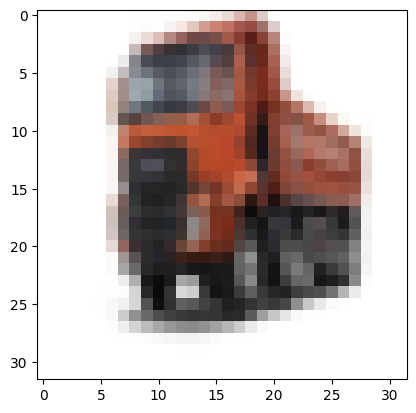

(1, 32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Model predicts:  truck
Result:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [ ]:
from keras.preprocessing import image
import numpy as np

img = tf.keras.preprocessing.image.load_img('truck.jpg', target_size=(32, 32), interpolation='bilinear')
plt.imshow(img)
plt.show()
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
print(img_array.shape)
result = model.predict(img_array)
whatIsIt = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predicted_classes = result.round()
predicted_index = np.where(predicted_classes == 1)[1]

print("Model predicts: ", whatIsIt[predicted_index[0]])
print("Result: ", result.round())

**Nota**: devido à maneira como foi implementado, não conseguimos apresentar gráficos de evolução das accuracies.